In [1]:
from copy import deepcopy as cp
from tqdm import tqdm
import numpy as np
import pandas as pd
import codecs
import re

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay
from experimental.display import create_tsne_for_plot
from experimental.metrics import bcb_clust

## Загрузка датасета

In [3]:
df = pd.read_pickle("statistics_and_text.pkl")
tlen = [len(elm) for elm in df["textInFile"]]
df["tlen"] = tlen
df = df[df["tlen"] > 100]

df = df[df['textInFile'].str.contains('УДК')]
n_pos_s = list(df['textInFile'].str.find('УДК'))

udk = []
udk2 = []
udk3 = []
udk31 = []
i = 0
for tx in tqdm(df['textInFile']):
    
    end = tx.find("\n", n_pos_s[i]+4)
    # print(tx[n_pos_s[i]+4:end])
    tx2 = tx[n_pos_s[i]+4:end].strip().replace("�", "-").replace("\t", ";").replace(" ", ";").replace(",", ";").replace("+", ";").replace(":", ";").replace("00", "0").replace(".", "")
    tx2 = re.sub("\([\w;.]+\)", "",tx2)
    tx2 = re.sub("[ ]+", " ",tx2)
    tx2 = tx2.replace(" - ", "-").split(";")
    tx2 = [tx_ for tx_ in tx2 if tx_ != "" and any(c.isalpha() for c in tx_) is False and len(tx_) < 25 and "�" not in tx_ and "?" not in tx_]
    #print(tx2)
    udk2_ = []
    udk2_2 = []
    
    for t in tx2:
        try:
            if t[:2] in ['01', '02', '04', '05', '06', '07', '30', '31', '32', '33', '34',
        '35', '36', '37', '50', '51', '52', '53', '54', '55', '57', '61',
        '62', '63', '65', '66', '68']:
                udk2_.append(t[:2])
                udk2_2.append(t[0])
        except:
            continue
    udk.append(np.unique(udk2_).tolist())
    udk3.append("".join(np.unique(udk2_).tolist()))
    udk31.append("".join(np.unique(udk2_2).tolist()))
    # print(udk[-1])
    udk2.append(len(udk[-1]))
    i += 1

df["УДК"] = udk
df["УДК-sp1"] = udk3
df["УДК-sp2"] = udk31
df["УДК-ln"] = udk2
print(len(df["textInFile"]))
df = df[df["УДК-ln"] != 0]
print(len(df["textInFile"]))
good_texts = []

100%|██████████| 4350/4350 [00:00<00:00, 11429.26it/s]

4350
4246


## Предобработка

1. Добавить проверку на то, что перед нами слова русского языка (а не рандомные наборы букв, такое бывает)

In [4]:
all_texts = list(df["textInFile"])
all_udcc = [int(elm[0]) for elm in list(df["УДК-sp2"])]

In [5]:
np.random.seed(0)
selection_ids = np.random.choice(len(all_texts), 500, replace=False, )
all_texts = [all_texts[i] for i in selection_ids]
all_udcc = [all_udcc[i] for i in selection_ids]

In [6]:
## удаление лишних символов, удаление необрабатываемых символов, удаление слишком коротких текстов.

red_texts = []
red_udcc = []
for i in tqdm(range(len(all_texts))):
    rt = all_texts[i].replace('-\n', '')
    rt = rt.replace('\n', ' ')
    rt = re.sub(r'[^а-яё.,:()\[\]0-9А-Я]', ' ', rt)
    # rt = re.sub(r'\s[а-яё.,:()0-9А-Я]\s', ' ', rt)
    rt = rt.replace(' . ', ' ')
    rt = re.sub('\s+', ' ', rt)
    rt = rt.split('.')
    rt = '. '.join([elm.strip() for elm in rt if elm.strip() !=''])
    if(len(rt) > 300):
        if red_texts != [] and red_texts[-1] == rt:
            continue
        red_texts.append(rt)
        red_udcc.append(all_udcc[i])

100%|██████████| 500/500 [00:08<00:00, 60.54it/s] 


In [7]:
## Разделение текстов на фрагменты (предложения). Удаление слишком длинных предложений
split_texts = []
for cur_text in tqdm(red_texts):
    split_text = []
    join_next = False
    keywords_rem = False
    cnt = -1
    ps = None
    
    for sent in re.split(r'([а-яё]\. )', cur_text):
        cnt += 1
        if cnt % 2 != 0:
            sent = ps + sent[:-2]
        else:
            ps = cp(sent)
            continue


        # останавливаемся, если дошли до списка литературы
        if re.search('список литературы', sent.lower()) is not None: 
            break
        
        if len(sent) > 1000:
            continue
        if len(sent) < 30:
            continue
        
        # убираем предложения, где слишком много больших букв
        if len(re.findall(r'[А-ЯЁ]', sent))/len(sent) > 0.5:
            continue
        # убираем предложения, где слишком много цифр
        if len(re.findall(r'[0-9()[]]', sent))/len(sent) > 0.5:
            continue
        # убираем предложения, где все слова начинаются с большой буквы
        if len(re.findall(r'[А-ЯЁ]', sent)) >= len(sent.split(' ')):
            continue
        # убираем предложение с ключевыми словами (но лишь раз)
        if re.search('ключевые слова', sent.lower()) is not None and not keywords_rem: 
            keywords_rem = True
            continue

        ## убираем последовательности цифр
        sent = re.sub(r'\b(?:[\d.,:()\[\]]\s*){4,}\d\b', '', sent)
        ## убираем последовательности больших букв
        sent = re.sub(r'\b(?:[А-ЯЁ]\s*){4,}\b', '', sent)

        
        if join_next:
            # print("joining")
            split_text[-1] = split_text[-1] + " " + sent
            join_next = False
            continue

        # if len(sent) < 100:
        #     join_next = True
        #     split_text.append(sent)
        #     continue       

        # про несправедливые разбиения
        if (not re.search("рис$",sent.lower()) is None) or (not re.search("табл$",sent.lower()) is None):
            # print("will join")
            join_next = True
            split_text.append(sent)
            continue
        
        # print("adding")
        split_text.append(sent)
    # for i in (split_text):
    #     print(i)
    split_texts.append(split_text)

100%|██████████| 500/500 [00:08<00:00, 60.75it/s] 


In [8]:
split_texts[2]

['Аннотация: В рамках анизотропийной теории управления (. ,. ,. ) обращение средней анизотропийной нормы системы в нуль соответствует 2 теории, а обращение в бесконечность При этом естественным образом возникает вопрос, с какого значения анизотропийной нормы ее следует считать близкой к нулю или близкой к бесконечности, а какие значения не близки ни к нулю, ни к бесконечности',
 'В настоящей работе предлагается метод построения нормированной (то есть принимающей значения в единичном интервале) анизотропийной нормы случайного вектора как выбор соответствующего отображения положительной полуоси в единичный интервал',
 'В основополагающей работе [1] введены анизотропийные нормы случайного вектора и линейных систем',
 'Как следствие, были получены многочисленные значимые результаты в соответствующей области теории управления, например [2 11]. Цель исследований [1 11] объединить в рамках единого подхода к теории оптимального управления особенности как 2 , так и методов, основанных на 2 и но

## Сегментация

#### Разделение на сегменты

In [9]:
# segment split model (1).
# В начале сегментируем какой-нибудь существующей моделью (скажем, texttiling)
# На вход идет текст, битый по предложениям, на выходе текст, битый по сегментам.
from experimental.segmentation import simple_segmentation_sentences
from experimental.segmentation import text_tiling_segmentation
from experimental.segmentation import segment_with_graphs

##### Нормализация и сохранение нормализованных текстов

In [10]:
from pymorphy3 import MorphAnalyzer
morph = MorphAnalyzer()

def pymorphy_parse_text(text):
    p_text = []
    for sent in text:
        p_text.append(' '.join([morph.parse(word)[0].normal_form for word in sent.split(' ')]))
    return p_text

In [11]:
split_texts_normalized = []
for text in tqdm(split_texts):
    split_texts_normalized.append(pymorphy_parse_text(text))

100%|██████████| 500/500 [14:43<00:00,  1.77s/it]  


In [12]:
from experimental.dset_loadings import create_and_save_dataframe
from experimental.dset_loadings import load_and_parse_dataframe

In [13]:
create_and_save_dataframe(split_texts, split_texts_normalized, all_udcc)
# split_texts, split_texts_normalized, all_udcc = load_and_parse_dataframe()

In [ ]:
# segmented_texts = []
# for split_text, split_text_normalized in tqdm(list(zip(split_texts,split_texts_normalized))):
#     segmented_texts.append(text_tiling_segmentation(split_text, split_text_normalized))

segmented_texts = []
for split_text, split_text_normalized in tqdm(list(zip(split_texts,split_texts_normalized))):
    if len(split_text) > 0:
        segmented_texts.append(segment_with_graphs(split_text, split_text_normalized))

  0%|          | 1/500 [00:00<01:14,  6.72it/s]

57
2128


  1%|          | 4/500 [00:06<11:17,  1.37s/it]

31
59
100


  1%|          | 5/500 [00:06<08:20,  1.01s/it]

...

 64%|██████▍   | 319/500 [04:51<02:35,  1.16it/s]

75


 64%|██████▍   | 320/500 [04:51<02:44,  1.10it/s]

206
0


ValueError: need at least one array to concatenate

#### Классификация сегментов

In [ ]:
from similarity_module.similarity_measure.paper_similarity import get_sentence_embedding
from similarity_module.similarity_measure.paper_similarity import calculate_text_similarities
from similarity_module.segmentation_models.paper_segmentation_model import text_segment_classifier

c:\Users\max\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
segment_model = text_segment_classifier("similarity_module/segmentation_models/full_model_segmentation_0.74_.wt", only_cpu= True)

loading base model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mlsa-iai-msu-lab/sci-rus-tiny3 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


reconfiguring classifier head...
loading new weights...


Device set to use cpu


done!


In [ ]:
all_text_segmented = []
for text in tqdm(segmented_texts):
    text_dict = {}
    preds = segment_model.mass_predict(text, verbal = False)
    for i in range(len(preds)):
        text_dict.setdefault(preds[i],[])
        text_dict[preds[i]].append(text[i])
    all_text_segmented.append(text_dict)

  0%|          | 0/478 [00:00<?, ?it/s]c:\Users\max\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Token indices sequence length is longer than the specified maximum sequence length for this model (1502 > 1024). Running this sequence through the model will result in indexing errors
  0%|          | 0/478 [00:00<?, ?it/s]


RuntimeError: The expanded size of the tensor (1502) must match the existing size (1026) at non-singleton dimension 1.  Target sizes: [1, 1502].  Tensor sizes: [1, 1026]

## Векторизация

In [ ]:
available_tags = list(segment_model.pipeline.model.config.label2id.keys())

In [ ]:
all_text_vectorized = []
for text in tqdm(all_text_segmented):
    elm_dict = {tag : None for tag in available_tags}
    for tag in text:
        elm_dict[tag] = np.array([get_sentence_embedding(sent) for sent in text[tag]])
    all_text_vectorized.append(elm_dict)

100%|██████████| 478/478 [26:23<00:00,  3.31s/it]  


In [ ]:
elm_dict.keys()

dict_keys(['Algo', 'Goal', 'None', 'Obl', 'Resl'])

## Измерение близости

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
def ot_text_sim_func(lhs_vectors, rhs_vectors):
    return cosine_similarity(lhs_vectors, rhs_vectors)

In [ ]:
text_similarities_matrix = np.zeros((len(all_text_vectorized), len(all_text_vectorized), len(available_tags[:])))
for i in tqdm(range(len(all_text_vectorized))):
    for j in range(i, len(all_text_vectorized)):
        t_sims = calculate_text_similarities(all_text_vectorized[i], all_text_vectorized[j], compare_sentences = True, selection_method = 5, comparation_method=ot_text_sim_func)
        text_similarities_matrix[i][j] = np.array(list(t_sims.values())[:])
## заполняем вторую половину матрицы
for i in range(len(text_similarities_matrix)):
    for j in range(0,i):
        text_similarities_matrix[i,j] = text_similarities_matrix[j,i]

100%|██████████| 478/478 [06:22<00:00,  1.25it/s]


Matplotlib is building the font cache; this may take a moment.


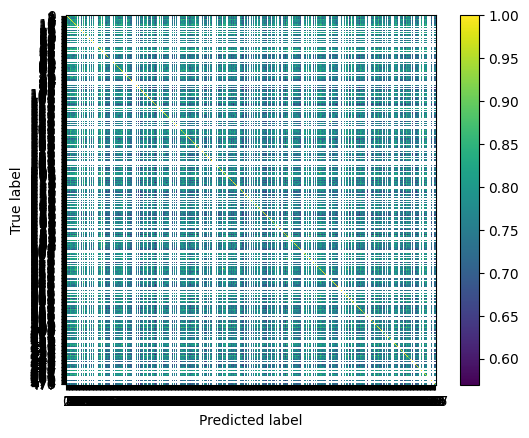

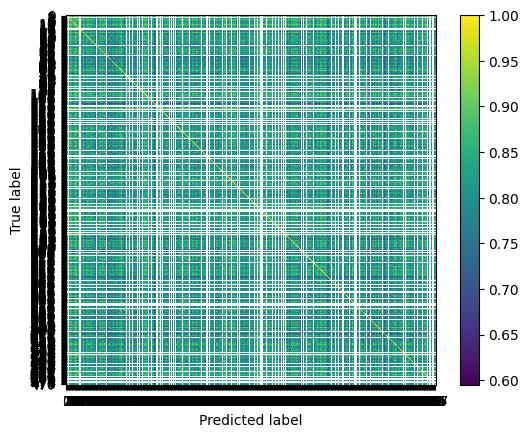

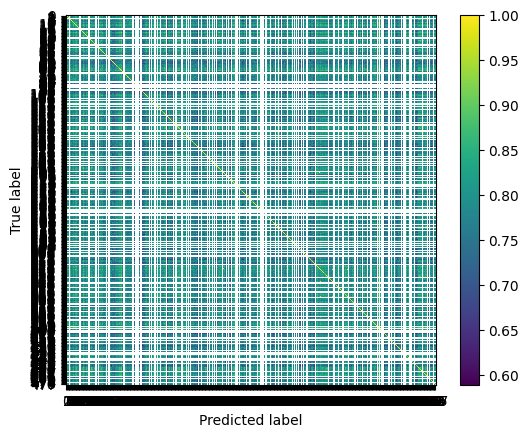

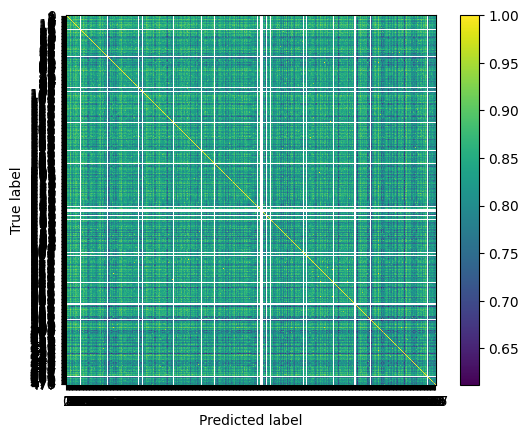

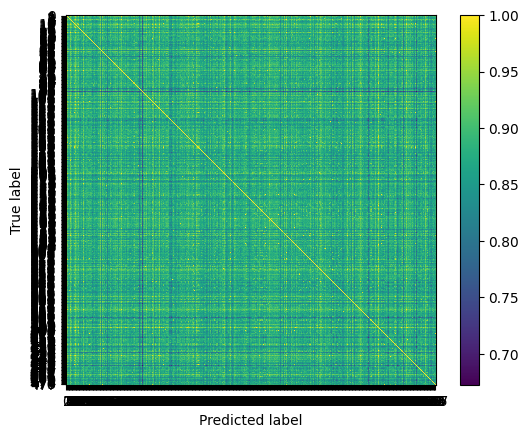

In [ ]:
import pylab

disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,0], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,1], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,2], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,3], display_labels = None)
disp.plot(include_values = False)
pylab.show()
disp = ConfusionMatrixDisplay(text_similarities_matrix[:,:,4], display_labels = None)
disp.plot(include_values = False)
pylab.show()

In [ ]:
text_similarities_matrix = np.nan_to_num(text_similarities_matrix, nan = 1e-3)

## Кластеризация (?)

In [ ]:
true_clusters = red_udcc

In [ ]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,0])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,1])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,2])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,3])
print(bcb_clust(clustering.labels_, true_clusters))
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=len(np.unique(true_clusters)), affinity='precomputed', random_state = 0).fit(text_similarities_matrix[:,:,4])
print(bcb_clust(clustering.labels_, true_clusters))

(0.3434052377042864, 0.34400262729604214, 0.3360737898713183)
(0.36418760309957976, 0.3541822501941842, 0.355673700702914)
(0.30858957035449897, 0.29489402060968645, 0.2971444007661472)
(0.38621873665620327, 0.44152271419106803, 0.4014702585765535)
(0.3221752042477324, 0.3304081366578524, 0.3209199057620864)


In [ ]:
import random
import numpy as np

def random_segmentation(true_seg):
    claster_count = len(np.unique(true_seg))
    random_clasters = []
    for _ in true_seg:
        random_clasters.append(random.choice(range(claster_count)))
    return random_clasters

bcb_clust(random_segmentation(true_clusters), true_clusters)

(0.25948843618092454, 0.25698285372279395, 0.2566597424362226)

## Оценка